# TUTORIAL-I: Introduction to Bfrescox
**Ozge Surer (Northwestern), Filomena Nunes (Michigan State), Matt Plumlee (Northwestern), Stefan Wild (Argonne)**


## Introduction to `frescox`

This notebook describes how to install `frescox` to run a scattering code for coupled-channels calculations.

`frescox` is publicly available at the repo https://github.com/LLNL/Frescox; more detailed documentation for earlier versions of `frescox` can be found at http://www.fresco.org.uk.

More information to install `frescox` to your machine and Bayesian calibration can be found at https://github.com/bandframework/bandframework/tree/development/software/Bfrescox.

In this tutorial, we use a Colab notebook,  which allows you to run the code in an interactive and consistent environment. You can then modify this code and run it on your preferred system(s).


We start by verifying that the code works as expected and then we perform a Bayesian calibration.

To do that, we need to install `frescox`:

In [1]:
%%bash
cd /content
git clone --branch v0.2.0 https://github.com/bandframework/bandframework.git
git clone https://github.com/LLNL/Frescox.git
mkdir Frescoxex
cp bandframework/software/Bfrescox/makefiles/googlecolab/makefile Frescox/source/
cd Frescox/source
make
make install
make clean

gfortran -Wall -w  -cpp -c -O2  globx7.f
gfortran -Wall -w  -cpp -c -O2  version_number.f
gfortran -Wall -w  -cpp -O1 -c frxx1.f
gfortran -Wall -w  -cpp -c -O2  frxx2.f
gfortran -Wall -w  -cpp -c -O2  frxx3.f
gfortran -Wall -w  -cpp -c -O2  frxx3b.f
gfortran -Wall -w  -cpp -c -O2  f14arm64.f
gfortran -Wall -w  -cpp -c -O2  frxx0.f
gfortran -Wall -w  -cpp -c -O2  frxx4.f
gfortran -Wall -w  -cpp -c -O2  frxx7a.f
gfortran -Wall -w  -cpp -c -O2  frxx5.f
gfortran -Wall -w  -cpp -c -O2  frxx6.f
gfortran -Wall -w  -cpp -c -O2  erwinrc4.f
gfortran -Wall -w  -cpp -c -O2  frxx7b.f
gfortran -Wall -w  -cpp -c -O2  frxx8.f
gfortran -Wall -w  -cpp -c -O2  frxx9.f
gfortran -Wall -w  -cpp -c -O2  frxx10.f
gfortran -Wall -w  -cpp -c -O2  frxx11.f
gfortran -Wall -w  -cpp -c -O2  bincc.f
gfortran -Wall -w  -cpp -c -O2  frxx13.f
gfortran -Wall -w  -cpp -c -O2  frxx16.f
gfortran -Wall -w  -cpp -c -O2  frxx17.f
gfortran -Wall -w  -cpp -c -O2  frxx21.f
gfortran -Wall -w  -cpp -c -O2  lagmesh.f
gfortran -Wall

Cloning into 'bandframework'...
Note: switching to '0a97b9d2b868567ae28bf1deae7c7b9358ec61d2'.

You are in 'detached HEAD' state. You can look around, make experimental
changes and commit them, and you can discard any commits you make in this
state without impacting any branches by switching back to a branch.

If you want to create a new branch to retain commits you create, you may
do so (now or later) by using -c with the switch command. Example:

  git switch -c <new-branch-name>

Or undo this operation with:

  git switch -

Turn off this advice by setting config variable advice.detachedHead to false

Cloning into 'Frescox'...


## Running `frescox` through python

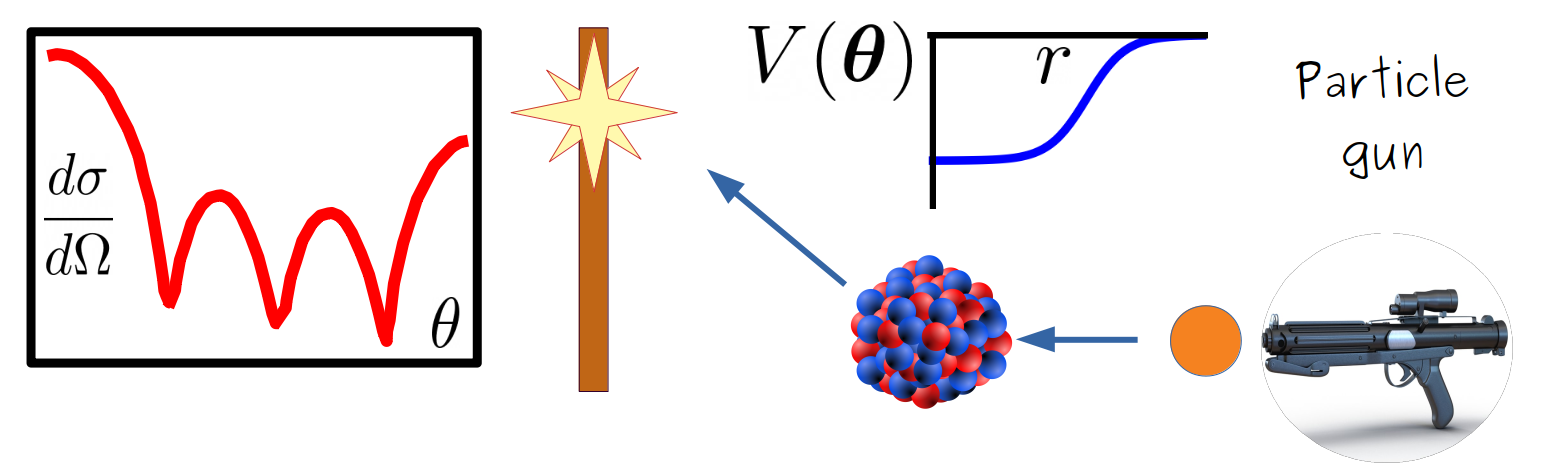

In [2]:
from IPython.display import Image
Image("/content/bandframework/software/Bfrescox/Tutorial_I/frescox.png")

To verify, we use a single-neutron transfer reaction, 48Ca(d,p)49Ca, which should reproduce the blue dotted and green dashed curves in Fig. 1 of [Lovell and Nunes, J. Phys. G: Nucl. Part. Phys. 2015](https://iopscience.iop.org/article/10.1088/0954-3899/42/3/034014/pdf).

This is a comparison of two different d+48Ca interactions. The corresponding input files are ``LH1048cadp.in`` and ``D1048cadp.in``.

Among other output, this frescox calculation will give us the deuteron elastic scattering cross section (Fig. 1a) and the transfer cross section (Fig. 1b).


In [3]:
import os
import subprocess
import matplotlib.pyplot as plt

commands = '''
  export PATH=$PATH:/content/Frescoxex
  cd /content/bandframework/software/Bfrescox/Tutorial_I/python_scripts
  mkdir frescox_outputs
  frescox < frescox_inputs/D1048cadp.in > frescox_outputs/D1048cadp.out
  frescox < frescox_inputs/LH1048cadp.in > frescox_outputs/LH1048cadp.out
'''
bashresults = subprocess.run(commands, capture_output=True, shell=True)

## Reading from the outputs

In [4]:
os.chdir("/content/bandframework/software/Bfrescox/Tutorial_I/python_scripts")
files = ['frescox_outputs/LH1048cadp.out', 'frescox_outputs/D1048cadp.out']
outs = []
for file in files:
    with open(file) as f:
        content = f.readlines()
        outs.append(content)

In [5]:
Rlist, slist = [], []
for out in outs:
    Rutherford = []
    sigma_omega_ratio = []
    for idline, line in enumerate(out):
        if '/R' in line:
            Rutherford.append(float(line.split()[3]))
        if (idline > 575) and ('X-S' in line):
            sigma_omega_ratio.append(float(line.split()[4]))

    Rlist.append(Rutherford)
    slist.append(sigma_omega_ratio)

# Visualize the outputs

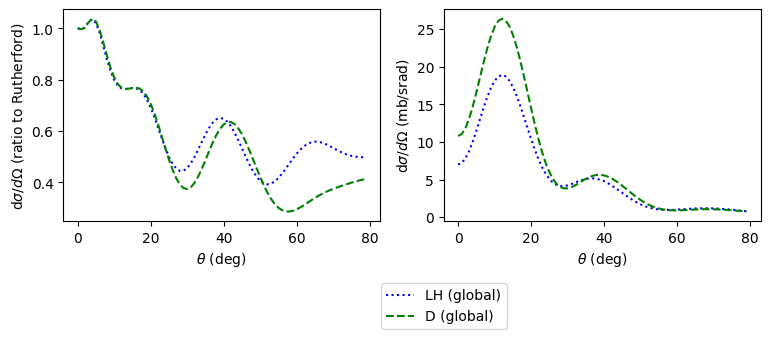

In [6]:
i = 0
fig, axes = plt.subplots(1, 2, figsize=(9,4))
for values in [Rlist, slist]:
    axes[i].plot(values[0][0:80], linestyle='dotted', c='blue', label='LH (global)')
    axes[i].plot(values[1][0:80], linestyle='dashed', c='green', label='D (global)')
    i += 1
fig.subplots_adjust(bottom=0.35)
plt.legend(bbox_to_anchor=(0, -0.4), loc='center')
axes[0].set_xlabel(r'$\theta$ (deg)')
axes[0].set_ylabel(r'd$\sigma/d\Omega$ (ratio to Rutherford)')
axes[1].set_xlabel(r'$\theta$ (deg)')
axes[1].set_ylabel(r'd$\sigma/d\Omega$ (mb/srad)')
plt.show()